In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Libraries imported successfully: TensorFlow, NumPy, Matplotlib, Seaborn.")

Libraries imported successfully: TensorFlow, NumPy, Matplotlib, Seaborn.


In [ ]:
df = pd.read_csv("activity_sessions.csv")

In [ ]:
df.head()

,session_id,user_id,machine_id,source,sequence,sequence_length,avg_latency_ms,total_bytes_out,error_count,failed_auth_count,is_anomaly
0,sess_02165,user_063,server_11,server,LOGIN AUTH_FAILURE AUTH_FAILURE AUTH_FAILURE H...,6,181.67,234605,4,3,1
1,sess_02231,user_094,server_08,git,LOGIN CLONE LOGOUT READ_FILE COMMIT PUSH,6,101.33,311727,0,0,0
2,sess_00447,user_051,server_12,git,LOGIN DOWNLOAD DOWNLOAD DOWNLOAD DELETE_REPO,5,66.00,15048751,0,0,1
3,sess_04009,user_055,server_12,git,LOGIN PULL LOGOUT PULL READ_FILE COMMIT PUSH,7,93.71,322658,0,0,0
4,sess_01626,user_030,server_18,server,LOGIN HTTP_GET CACHE_READ HTTP_GET DB_READ LOGOUT,6,98.50,327084,0,0,0


In [ ]:
print(df.isnull().sum())

session_id           0
user_id              0
machine_id           0
source               0
sequence             0
sequence_length      0
avg_latency_ms       0
total_bytes_out      0
error_count          0
failed_auth_count    0
is_anomaly           0
dtype: int64


In [ ]:
print(df["is_anomaly"].value_counts())
print(df["is_anomaly"].value_counts(normalize=True))

is_anomaly
0    4418
1     582
Name: count, dtype: int64
is_anomaly
0    0.8836
1    0.1164
Name: proportion, dtype: float64


In [ ]:
print(df["sequence_length"].describe())

count    5000.00000
mean        6.53260
std         0.71487
min         5.00000
25%         6.00000
50%         6.00000
75%         7.00000
max         8.00000
Name: sequence_length, dtype: float64


In [ ]:
print(df["sequence_length"].value_counts().sort_index())

sequence_length
5     228
6    2308
7    2037
8     427
Name: count, dtype: int64


In [ ]:
normal = df[df["is_anomaly"] == 0]
anomaly = df[df["is_anomaly"] == 1]

print("NORMAL")
print(normal["sequence"].head(10).to_string(index=False))

print("\nANOMALY")
print(anomaly["sequence"].head(10).to_string(index=False))

NORMAL
          LOGIN CLONE LOGOUT READ_FILE COMMIT PUSH
      LOGIN PULL LOGOUT PULL READ_FILE COMMIT PUSH
 LOGIN HTTP_GET CACHE_READ HTTP_GET DB_READ LOGOUT
LOGIN DB_READ HTTP_GET DB_WRITE HTTP_POST CACHE...
LOGIN PULL READ_FILE CREATE_BRANCH PUSH COMMIT ...
LOGIN READ_FILE CLONE READ_FILE PUSH COMMIT LOGOUT
LOGIN HTTP_GET DB_WRITE LOGOUT DB_READ CACHE_RE...
 LOGIN HTTP_GET CACHE_READ HTTP_GET LOGOUT DB_READ
LOGIN PULL CREATE_BRANCH READ_FILE COMMIT LOGOU...
LOGIN PULL READ_FILE COMMIT PUSH READ_FILE PULL...

ANOMALY
LOGIN AUTH_FAILURE AUTH_FAILURE AUTH_FAILURE HT...
      LOGIN DOWNLOAD DOWNLOAD DOWNLOAD DELETE_REPO
LOGIN FAILED_LOGIN FAILED_LOGIN DOWNLOAD DELETE...
LOGIN ERROR_500 HTTP_GET ERROR_500 ERROR_500 DB...
LOGIN AUTH_FAILURE AUTH_FAILURE HTTP_DELETE ERR...
LOGIN HTTP_GET HTTP_GET ERROR_500 HTTP_GET HTTP...
LOGIN FAILED_LOGIN FAILED_LOGIN DOWNLOAD FAILED...
    LOGIN CLONE DELETE_REPO DOWNLOAD DOWNLOAD PUSH
    LOGIN CLONE DOWNLOAD PUSH DOWNLOAD DELETE_REPO
LOGIN HTTP_GET 

In [ ]:
events = set()

for sequence in df["sequence"]:
    events.update(sequence.split())

events = sorted(events)

event_to_id = {
    event: i + 1
    for i, event in enumerate(events)
}

print(event_to_id)

{'AUTH_FAILURE': 1, 'CACHE_READ': 2, 'CACHE_WRITE': 3, 'CLONE': 4, 'COMMIT': 5, 'CREATE_BRANCH': 6, 'DB_READ': 7, 'DB_WRITE': 8, 'DELETE_REPO': 9, 'DOWNLOAD': 10, 'ERROR_500': 11, 'FAILED_LOGIN': 12, 'FILE_DOWNLOAD': 13, 'HTTP_DELETE': 14, 'HTTP_GET': 15, 'HTTP_POST': 16, 'LOGIN': 17, 'LOGOUT': 18, 'PULL': 19, 'PUSH': 20, 'READ_FILE': 21}


In [ ]:
def encode_sequence(sequence):
    return [
        event_to_id[event]
        for event in sequence.split()
    ]

df["encoded_sequence"] = df["sequence"].apply(
    encode_sequence
)

print(df[["sequence", "encoded_sequence"]].head())

                                            sequence  \
0  LOGIN AUTH_FAILURE AUTH_FAILURE AUTH_FAILURE H...   
1           LOGIN CLONE LOGOUT READ_FILE COMMIT PUSH   
2       LOGIN DOWNLOAD DOWNLOAD DOWNLOAD DELETE_REPO   
3       LOGIN PULL LOGOUT PULL READ_FILE COMMIT PUSH   
4  LOGIN HTTP_GET CACHE_READ HTTP_GET DB_READ LOGOUT   

              encoded_sequence  
0        [17, 1, 1, 1, 14, 11]  
1       [17, 4, 18, 21, 5, 20]  
2          [17, 10, 10, 10, 9]  
3  [17, 19, 18, 19, 21, 5, 20]  
4       [17, 15, 2, 15, 7, 18]  


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    df["encoded_sequence"],
    maxlen=10,
    padding="post",
    truncating="post",
    value=0
)
y = df["is_anomaly"].values

In [ ]:
print(X.shape)
print(X[:5])

(5000, 10)
[[17  1  1  1 14 11  0  0  0  0]
 [17  4 18 21  5 20  0  0  0  0]
 [17 10 10 10  9  0  0  0  0  0]
 [17 19 18 19 21  5 20  0  0  0]
 [17 15  2 15  7 18  0  0  0  0]]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Train:", X_train.shape, y_train.shape[0])
print("Validation:", X_val.shape, y_val.shape[0])
print("Test:", X_test.shape, y_test.shape[0])

Train: (3500, 10) 3500
Validation: (750, 10) 750
Test: (750, 10) 750


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [ ]:
MAX_LENGTH = 10
EMBEDDING_DIM = 32
LSTM_UNITS = 64

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

VOCAB_SIZE = len(event_to_id)

with tf.device('/CPU:0'):
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE + 1,
            output_dim=EMBEDDING_DIM
        ),
        LSTM(LSTM_UNITS),
        Dense(1, activation="sigmoid")
    ])

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
with tf.device('/CPU:0'):

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=1
    )

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 3.9395e-06 - val_accuracy: 1.0000 - val_loss: 9.6404e-07
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.1002e-07 - val_accuracy: 1.0000 - val_loss: 3.8598e-07
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.8978e-07 - val_accuracy: 1.0000 - val_loss: 2.1714e-07
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.7614e-07 - val_accuracy: 1.0000 - val_loss: 1.4240e-07
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.2055e-07 - val_accuracy: 1.0000 - val_loss: 1.0172e-07
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 8.8655e-08 - val_accuracy: 1.0000 - val_loss: 7.6958e-08
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.8452e-08 - val_accuracy: 1.0000 - val_loss: 6.0496e-08
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

In [ ]:
import tensorflow as tf

with tf.device('/CPU:0'):
    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test
    )

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 9.9644e-06 
Test loss: 9.964379387383815e-06
Test accuracy: 1.0


In [ ]:
import tensorflow as tf
import numpy as np

sequence = ["LOGIN", "PULL", "READ_FILE", "COMMIT"]
encoded = [
    event_to_id[event]
    for event in sequence
]

input_sequence = pad_sequences(
    [encoded],
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

with tf.device('/CPU:0'):
    prediction = model.predict(input_sequence)

anomaly_probability = prediction[0][0]
is_anomaly_predicted = int(anomaly_probability > 0.5)

print(f"Anomaly Probability: {anomaly_probability:.6f}")
print(f"Predicted Class: {is_anomaly_predicted} (Anomaly)" if is_anomaly_predicted == 1 else f"Predicted Class: {is_anomaly_predicted} (Normal)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Anomaly Probability: 0.000004
Predicted Class: 0 (Normal)


In [ ]:
import pandas as pd
import tensorflow as tf

with tf.device('/CPU:0'):
    anomaly_scores = model.predict(X_test)

scores_df = pd.DataFrame({
    'True_Label': y_test,
    'Anomaly_Score': anomaly_scores.flatten()
})

print("=== Summary of Anomaly Scores ===")
display(scores_df.describe())

print("\n=== Top 5 Most Confident Anomalies (High Score) ===")
display(scores_df[scores_df['True_Label'] == 1].sort_values(by='Anomaly_Score', ascending=False).head())

print("\n=== Top 5 Most Confident Normal Sessions (Low Score) ===")
display(scores_df[scores_df['True_Label'] == 0].sort_values(by='Anomaly_Score', ascending=True).head())

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
=== Summary of Anomaly Scores ===


,True_Label,Anomaly_Score
count,750.000000,750.000000
mean,0.116000,0.116000
std,0.320439,0.320423
min,0.000000,0.000004
25%,0.000000,0.000005
50%,0.000000,0.000005
75%,0.000000,0.000006
max,1.000000,0.999962



=== Top 5 Most Confident Anomalies (High Score) ===


,True_Label,Anomaly_Score
482,1,0.999962
661,1,0.999962
616,1,0.999962
567,1,0.999962
221,1,0.999962



=== Top 5 Most Confident Normal Sessions (Low Score) ===


,True_Label,Anomaly_Score
389,0,0.000004
431,0,0.000004
272,0,0.000004
6,0,0.000004
197,0,0.000004


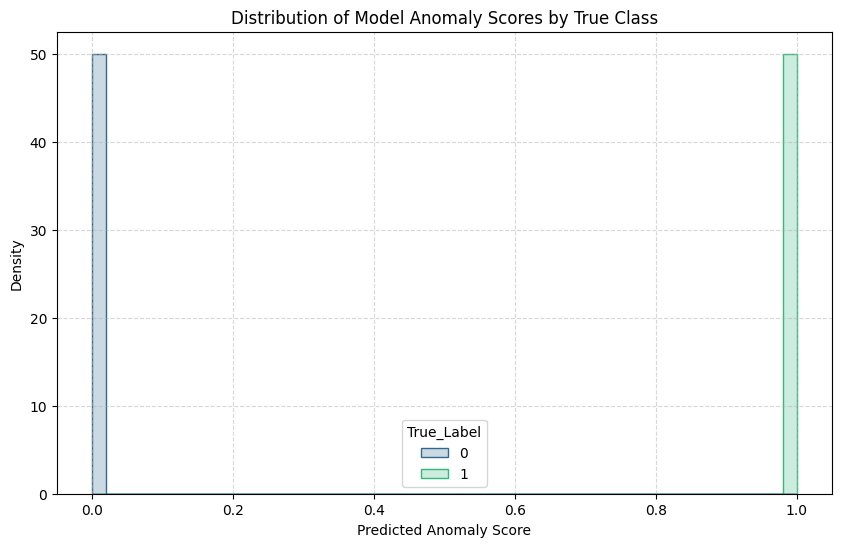

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(
    data=scores_df,
    x='Anomaly_Score',
    hue='True_Label',
    element='step',
    stat='density',
    common_norm=False,
    bins=50,
    palette='viridis'
)
plt.title('Distribution of Model Anomaly Scores by True Class')
plt.xlabel('Predicted Anomaly Score')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       663
           1       1.00      1.00      1.00        87

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750

=== Confusion Matrix ===


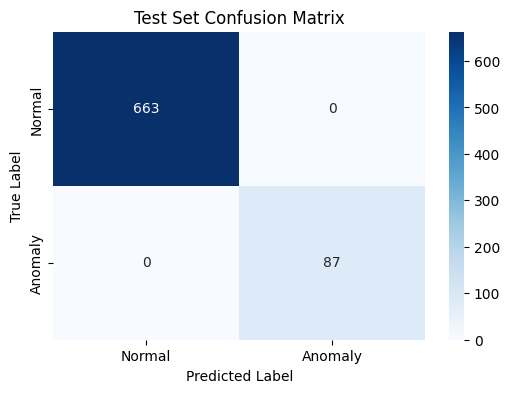

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_class = (scores_df['Anomaly_Score'] > 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(scores_df['True_Label'], y_pred_class))

print("=== Confusion Matrix ===")
cm = confusion_matrix(scores_df['True_Label'], y_pred_class)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       663
           1       1.00      1.00      1.00        87

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750

=== Confusion Matrix ===


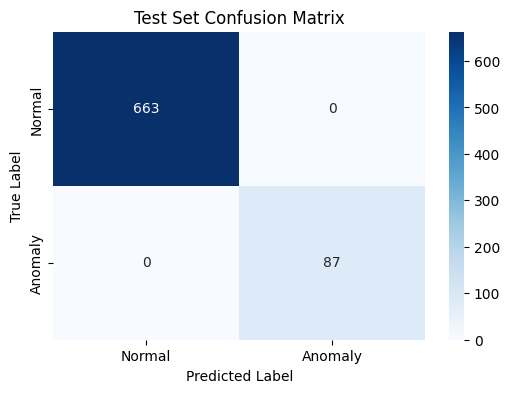

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_class = (scores_df['Anomaly_Score'] > 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(scores_df['True_Label'], y_pred_class))

print("=== Confusion Matrix ===")
cm = confusion_matrix(scores_df['True_Label'], y_pred_class)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()